# Image segmentation

## Training the segmentation head from embeddings.

In this notebook the user can train the model via LightningCLI using configurations in ```configs/train_embedding_classifier.yaml```. Moddify the batch size, learning rate, and other hyperparameters in the configuration file as needed.

This notebook uses a CSV logger by default for training, validation and test results. A [WandB logger](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.WandbLogger.html#lightning.pytorch.loggers.WandbLogger) can also be used. If you prefer the latter, please switch the loggers and update the entity of the WandB logger configuration in ```configs/train_embedding_classifier.yaml```.

In [1]:
import os
from pathlib import Path

def find_project_root(marker='claymodel'):
    current = Path.cwd()
    for path in [current] + list(current.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Project root not found")

os.chdir(find_project_root())

In [2]:
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.cli import LightningArgumentParser, instantiate_class

from claymodel.finetune.segment.embedding_classifier import EmbeddingClassifier
from claymodel.finetune.segment.embedding_datamodule import EmbeddingDataModule

from datetime import datetime

seed_everything(42)  # your seed here

def Train_segmentation_from_embeddings(config_path, test_after_training=False):
    
    objects = ["callbacks", "logger", "plugins"]

    # Create argument parser similar to LightningCLI
    parser = LightningArgumentParser()
    parser.add_lightning_class_args(EmbeddingClassifier, "model")
    parser.add_lightning_class_args(EmbeddingDataModule, "data")
    parser.add_lightning_class_args(Trainer, "trainer")
    
    # Parse the config file
    config = parser.parse_path(config_path)

    trainer_config = dict(config["trainer"])
    
    # Instantiate objects
    for object in objects:
        if object in trainer_config and trainer_config[object]:
            callbacks = []
            for callback_config in trainer_config[object]:
                if hasattr(callback_config, 'class_path') and hasattr(callback_config, 'init_args'):
                    # This is a Namespace object from CLI parsing
                    if object == "logger" and callback_config.class_path == "lightning.pytorch.loggers.CSVLogger":
                        callback_config.init_args['version'] = datetime.now().strftime("%Y%m%d_%H%M%S")
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)                    
                elif isinstance(callback_config, dict) and "class_path" in callback_config:
                    # This is a dictionary configuration
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)
                else:
                    # Already an instantiated callback
                    callbacks.append(callback_config)
            
            trainer_config[object] = callbacks
    
    # Create instances
    model = EmbeddingClassifier(**config["model"])
    datamodule = EmbeddingDataModule(**config["data"])
    trainer = Trainer(**trainer_config)

    result = trainer.fit(model, datamodule)
    if test_after_training:
        result = trainer.test(model, datamodule)
        print(model.confusion_matrix)

    print("Results:", result)
    
    return model, datamodule, trainer, result

Seed set to 42


In [3]:
model, *_ = Train_segmentation_from_embeddings("configs/train_embedding_classifier.yaml", test_after_training=True)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:701: Checkpoint directory /home/ignacio/Code/Clay-foundation/model/checkpoints/segment_embeddings exists and is not empty.
/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name              | Type                      | Params | Mode 
------------------------------------------------------------------------
0 | model             | EmbeddingSegmentationHead | 26.0 M | train
1 | loss_fn           | FocalLoss                 | 0      | train
2 | iou               | MulticlassJaccardIndex 

🏗️  EmbeddingClassifier initialized:
   Input: 1024 channels, 8 spatial
   Output: 6 classes, (224, 224) spatial


/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]

/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 32. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 8. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 32: 'val/iou' reached 0.83530 (best 0.83530), saving model to '/home/ignacio/Code/Clay-foundation/model/checkpoints/segment_embeddings/embedding-7class-segment_epoch-00_val-iou-0.8353-v6.ckpt' as top 2
`Trainer.fit` stopped: `max_epochs=1` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test/f1_epoch         0.8457033038139343
     test/iou_epoch         0.7648119330406189
     test/loss_epoch        0.17630615830421448
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
tensor([[ 2097516,    41172,    93203,        0,        0,        0],
        [  102731, 24821690,  2052264,        0,        0,        0],
        [  211640,  1637436, 16563945,        0,        0,        0],
        [    1750,     6507,    65008,        0,        0,        0],
        [  336462,   408238,   715398,        0,        0,        0],
        [  138818,   310875,   571347,        0,        0,        0]])
Results: [{'test/loss_epoch': 

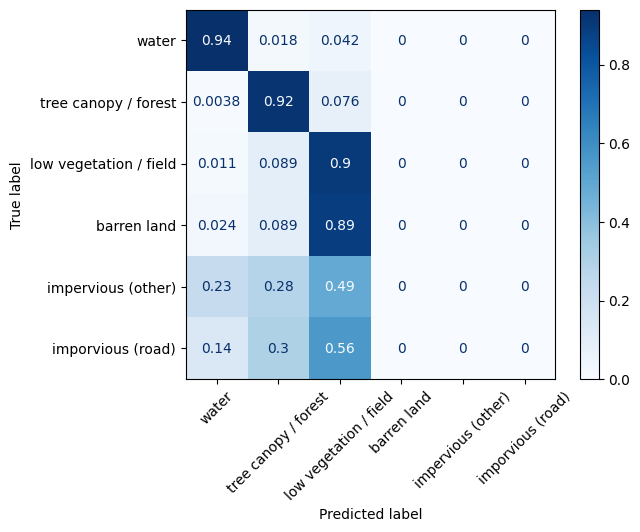

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

labels_map={0: "water", 1: "tree canopy / forest", 2: "low vegetation / field", 3: "barren land", 4: "impervious (other)", 5: "imporvious (road)"}

cm_normalized = model.confusion_matrix.numpy()

cm_normalized = cm_normalized.astype('float') / cm_normalized.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=labels_map.values())

disp.plot(cmap='Blues', xticks_rotation=45)


In [5]:
import matplotlib.pyplot as plt
import random
import torch
import yaml

def plot_random_n_chips(model, config_path_yaml, n=5, split="test"):   

    with open(config_path_yaml, 'r') as f:
        config_dict = yaml.safe_load(f)

    if split == "train":
        embedding_path = Path(config_dict['data']['train_embedd_dir'])
        labels_path = Path(config_dict['data']['train_label_dir'])
        chips_path = embedding_path.parent        
    elif split == "val":
        embedding_path = Path(config_dict['data']['val_embedd_dir'])
        labels_path = Path(config_dict['data']['val_label_dir'])
        chips_path = embedding_path.parent        
    elif split == "test":
        embedding_path = Path(config_dict['data']['test_embedd_dir'])
        labels_path = Path(config_dict['data']['test_label_dir'])
        chips_path = embedding_path.parent
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")
    
    map_labels={0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6}
    all_images = []
    all_labels = []
    all_embeddings = []
    chip_names = []

    embeddings_files = sorted([f for f in embedding_path.iterdir() if f.suffix == '.npy'])

    if n > len(embeddings_files):
        raise ValueError(f"n ({n}) is greater than the number of available embeddings ({len(embeddings_files)})")
    
    random_files = random.sample(embeddings_files, n)

    for file in random_files:        
        embeddings = np.load(file)
        chip = np.load(chips_path / file.name.replace('_emb', ''))
        labels = np.load(labels_path / file.name.replace('_emb', '').replace('naip-new', 'lc'))
        all_embeddings.append(embeddings)            
        all_images.append(chip)
        all_labels.append(labels)
        chip_names.append(file.name)
    
    # Predict
    model.eval()
    with torch.no_grad():
        pred = model({"embedding": torch.tensor(np.stack(all_embeddings), dtype=torch.float32)})        
    pred_np = pred.argmax(dim=1).numpy()    

    _, axs = plt.subplots(n, 3, figsize=(10, 5*n))
    
    for idx in range(n):
        image = np.moveaxis(all_images[idx][:3], 0, -1)
        label = all_labels[idx].squeeze()
        pred = pred_np[idx]        
        pred = np.vectorize(map_labels.get)(pred)
        
        axs[idx, 0].imshow(image)
        axs[idx, 0].set_title("Input Image")
        axs[idx, 0].axis('off')
        
        axs[idx, 1].imshow(label, cmap='jet', vmin=0, vmax=len(labels_map)-1)
        axs[idx, 1].set_title("True Segmentation")
        axs[idx, 1].axis('off')

        axs[idx, 2].imshow(pred, cmap='jet', vmin=0, vmax=len(labels_map)-1)
        axs[idx, 2].set_title("Predicted Segmentation")
        axs[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

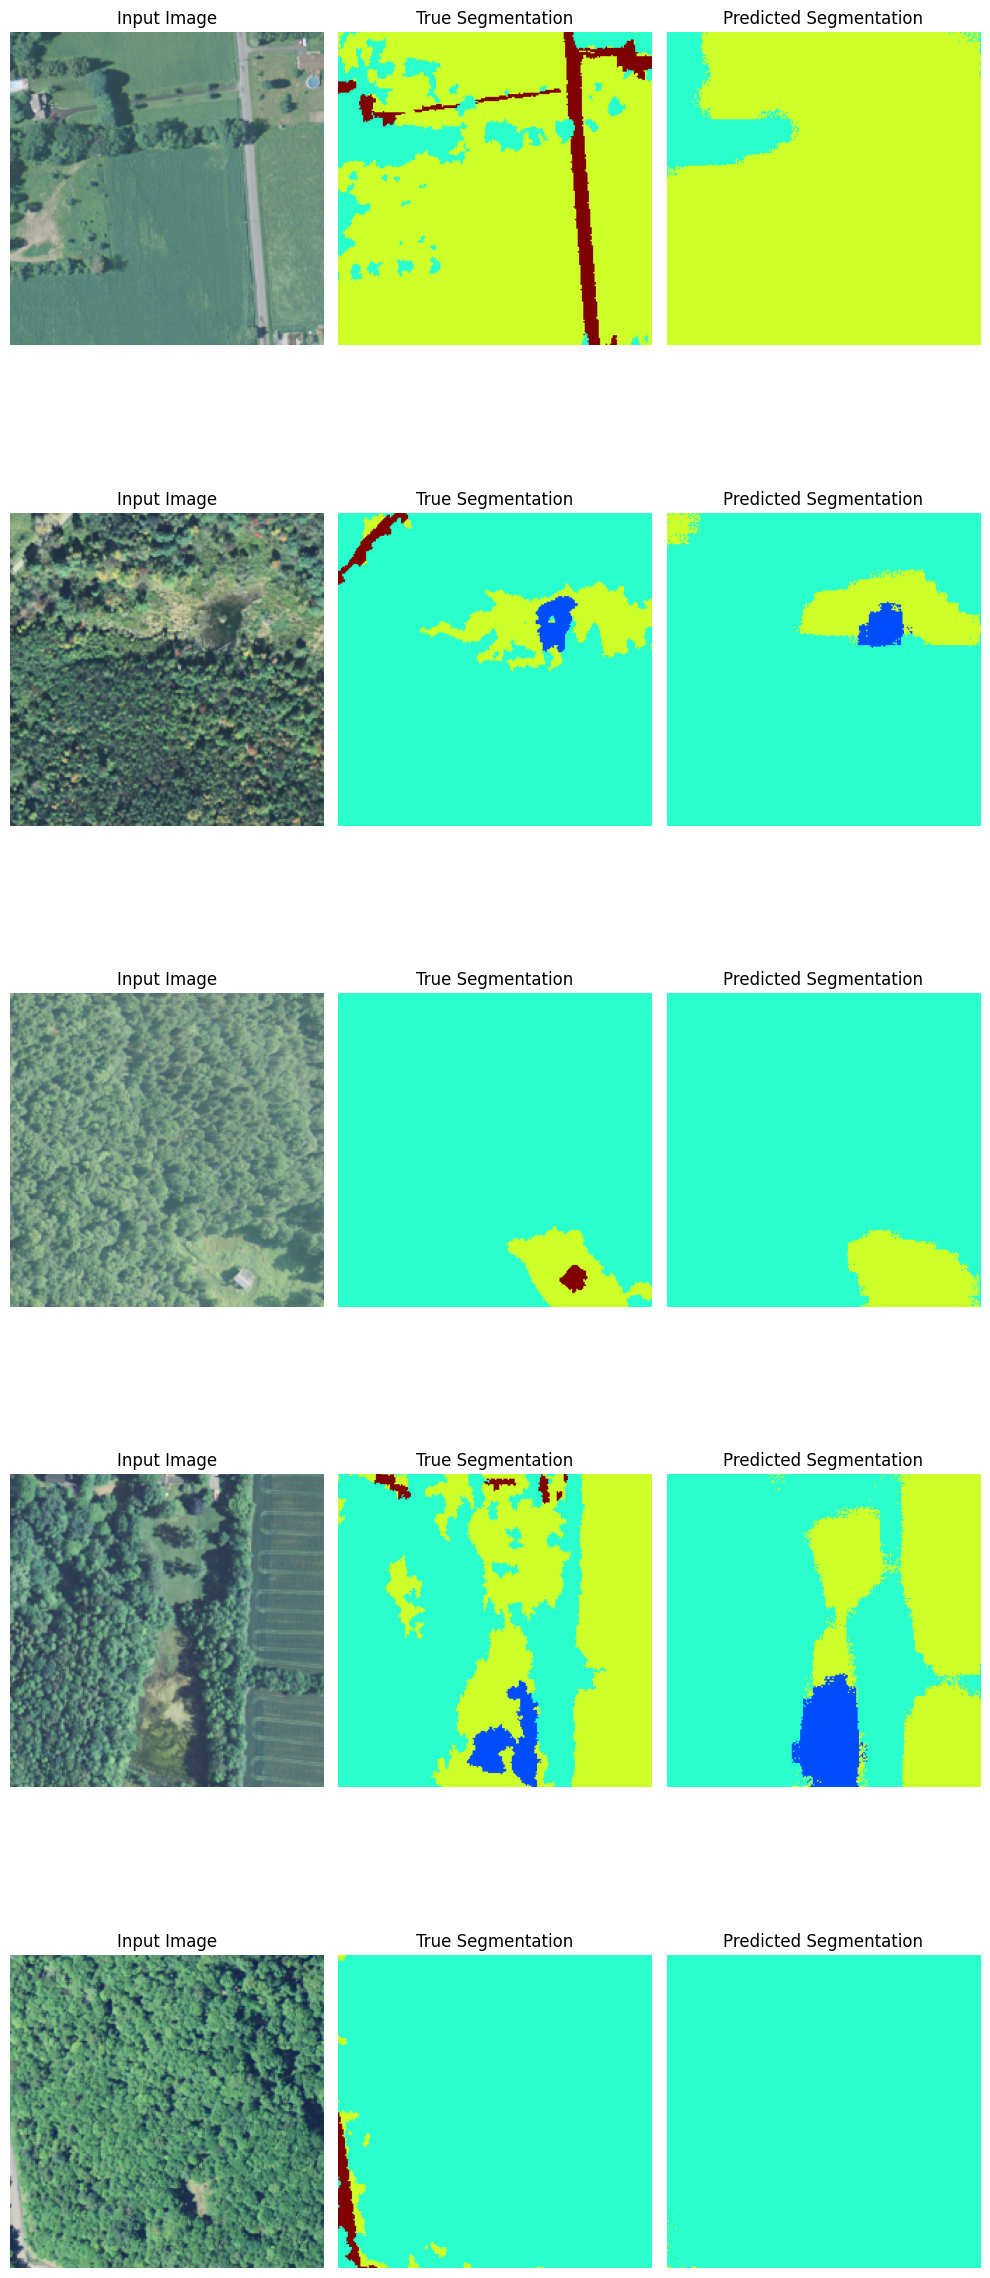

In [6]:
plot_random_n_chips(model, config_path_yaml="configs/train_embedding_classifier.yaml")